# Uncertainty Quantification for Out-of-Distribution Detection

**Master's Thesis Notebook — Trustworthy / Robust ML**

Research question: *How well do different uncertainty quantification (UQ) methods
detect out-of-distribution (OOD) inputs and produce reliable confidence estimates,
with a particular focus on conformal prediction?*

Methods compared:
- Softmax confidence (naive baseline)
- MC-Dropout
- Deep Ensembles (small, 3–5 models)
- Split Conformal Prediction (Adaptive Prediction Sets)

Datasets:
- In-distribution (ID): **CIFAR-10**
- Out-of-distribution (OOD): **SVHN**

See `README.md` for dataset links and setup instructions.


## 1. Setup & Environment

In [1]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid")
import time
from tqdm.auto import tqdm


e:\code\deeplearning_thesis\src\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
# --- Config block: change these to rerun experiments ---
CONFIG = {
    "id_dataset": "CIFAR10",
    "ood_dataset": "SVHN",
    "data_dir": "./data",
    "batch_size": 128,
    "num_epochs": 15,
    "lr": 1e-3,
    "n_ensemble_members": 5,
    "mc_dropout_passes": 30,
    "mc_dropout_p": 0.3,
    "conformal_alpha": 0.1,        # target 90% coverage
    "calib_fraction": 0.2,         # fraction of test set held out for conformal calibration
    "corruption_severities": [0.0, 0.05, 0.1, 0.2, 0.35, 0.5],  # gaussian noise std, stress test
}
CONFIG


{'id_dataset': 'CIFAR10',
 'ood_dataset': 'SVHN',
 'data_dir': './data',
 'batch_size': 128,
 'num_epochs': 15,
 'lr': 0.001,
 'n_ensemble_members': 5,
 'mc_dropout_passes': 30,
 'mc_dropout_p': 0.3,
 'conformal_alpha': 0.1,
 'calib_fraction': 0.2,
 'corruption_severities': [0.0, 0.05, 0.1, 0.2, 0.35, 0.5]}

## 2. Data

- ID dataset: **CIFAR-10** (10 classes, 32x32 RGB) — [link](https://www.cs.toronto.edu/~kriz/cifar.html)
- OOD dataset: **SVHN** (house numbers, 32x32 RGB, disjoint label semantics) — [link](http://ufldl.stanford.edu/housenumbers/)

Both are downloaded automatically via `torchvision.datasets` on first run.


In [4]:
import os
import time
import torchvision
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

cifar_root = CONFIG["data_dir"]
svhn_root = os.path.join(CONFIG["data_dir"], "svhn")

print(f"[data] cifar_root = {cifar_root}")
print(f"[data] svhn_root  = {svhn_root}")

assert os.path.isdir(os.path.join(cifar_root, "cifar-10-batches-py")), \
    f"Expected {cifar_root}/cifar-10-batches-py to exist. Check CONFIG['data_dir']."
assert os.path.isfile(os.path.join(svhn_root, "test_32x32.mat")), \
    f"Expected {svhn_root}/test_32x32.mat to exist. Check CONFIG['data_dir']."
print("[data] file checks passed, both datasets found locally.")

t0 = time.time()
print("[data] loading CIFAR-10 train split...")
id_train_full = torchvision.datasets.CIFAR10(root=cifar_root, train=True, download=False, transform=transform)
print(f"[data]   done in {time.time()-t0:.2f}s -> {len(id_train_full)} samples")

t0 = time.time()
print("[data] loading CIFAR-10 test split...")
id_test_full  = torchvision.datasets.CIFAR10(root=cifar_root, train=False, download=False, transform=transform)
print(f"[data]   done in {time.time()-t0:.2f}s -> {len(id_test_full)} samples")

t0 = time.time()
print("[data] loading SVHN test split...")
ood_test_full = torchvision.datasets.SVHN(root=svhn_root, split="test", download=False, transform=transform)
print(f"[data]   done in {time.time()-t0:.2f}s -> {len(ood_test_full)} samples")

print(f"[data] ID train: {len(id_train_full)} | ID test: {len(id_test_full)} | OOD test: {len(ood_test_full)}")


[data] cifar_root = ./data
[data] svhn_root  = ./data\svhn
[data] file checks passed, both datasets found locally.
[data] loading CIFAR-10 train split...
[data]   done in 0.82s -> 50000 samples
[data] loading CIFAR-10 test split...
[data]   done in 0.48s -> 10000 samples
[data] loading SVHN test split...
[data]   done in 0.93s -> 26032 samples
[data] ID train: 50000 | ID test: 10000 | OOD test: 26032


In [5]:
# Split ID test set into a calibration set (for conformal prediction) and an evaluation set
print("[split] building calibration/evaluation split...")
n_calib = int(len(id_test_full) * CONFIG["calib_fraction"])
idx = list(range(len(id_test_full)))
random.shuffle(idx)
calib_idx, eval_idx = idx[:n_calib], idx[n_calib:]

id_calib = Subset(id_test_full, calib_idx)
id_eval  = Subset(id_test_full, eval_idx)

train_loader = DataLoader(id_train_full, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
calib_loader = DataLoader(id_calib, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
eval_loader  = DataLoader(id_eval, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
ood_loader   = DataLoader(ood_test_full, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"[split] Calib: {len(id_calib)} | Eval: {len(id_eval)} | OOD: {len(ood_test_full)}")
print(f"[split] batches -> train: {len(train_loader)} | calib: {len(calib_loader)} | eval: {len(eval_loader)} | ood: {len(ood_loader)}")


[split] building calibration/evaluation split...
[split] Calib: 2000 | Eval: 8000 | OOD: 26032
[split] batches -> train: 391 | calib: 16 | eval: 63 | ood: 204


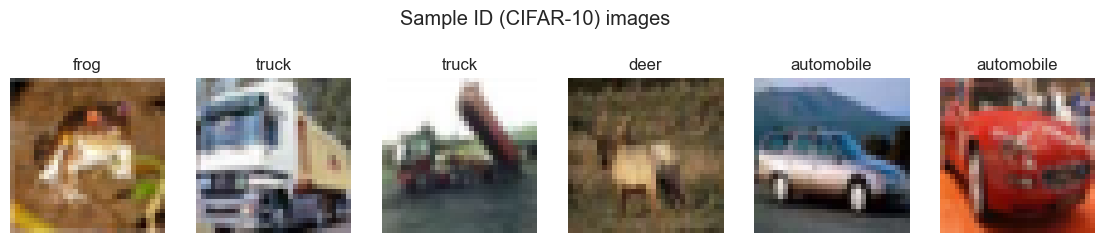

In [6]:
# Quick EDA: sample images + class balance
classes = id_train_full.classes
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    img, label = id_train_full[i]
    img = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")
plt.suptitle("Sample ID (CIFAR-10) images")
plt.show()


## 3. Base Model

A small CNN is used deliberately — the model itself is not the contribution,
the UQ analysis on top of it is. Keeping it small keeps training tractable on
limited / CPU-only compute.


In [7]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 8x8
        )
        self.dropout = nn.Dropout(dropout_p)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.dropout(x)
        return self.classifier(x)


In [8]:
def train_model(model, train_loader, num_epochs=CONFIG["num_epochs"], lr=CONFIG["lr"], verbose=True):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        t0 = time.time()
        batch_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False, disable=not verbose)
        for x, y in batch_iter:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
            if verbose:
                batch_iter.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | loss: {total_loss/total:.4f} | acc: {correct/total:.4f} | {time.time()-t0:.1f}s")
    return model


In [9]:
base_model = SmallCNN(dropout_p=CONFIG["mc_dropout_p"])
base_model = train_model(base_model, train_loader)


Epoch 1/15 | loss: 1.3838 | acc: 0.4972 | 96.0s


Epoch 2/15 | loss: 0.9878 | acc: 0.6515 | 97.6s


Epoch 3/15 | loss: 0.8550 | acc: 0.6999 | 106.5s


Epoch 4/15 | loss: 0.7671 | acc: 0.7330 | 100.2s


Epoch 5/15 | loss: 0.7052 | acc: 0.7549 | 99.0s


...

Epoch 11/15 | loss: 0.4937 | acc: 0.8255 | 97.5s


Epoch 12/15 | loss: 0.4706 | acc: 0.8336 | 97.5s


Epoch 13/15 | loss: 0.4533 | acc: 0.8371 | 97.5s


Epoch 14/15 | loss: 0.4309 | acc: 0.8455 | 97.6s


Epoch 15/15 | loss: 0.4236 | acc: 0.8486 | 96.6s


In [10]:
@torch.no_grad()
def evaluate_accuracy(model, loader, desc="evaluate"):
    model.eval()
    correct, total = 0, 0
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct / total

t0 = time.time()
baseline_acc = evaluate_accuracy(base_model, eval_loader, desc="baseline eval")
print(f"Baseline ID test accuracy: {baseline_acc:.4f} ({time.time()-t0:.1f}s)")


Baseline ID test accuracy: 0.8013 (6.4s)


## 4. Uncertainty Quantification Methods

Each subsection implements one UQ method and produces, for every input:
- a predicted class
- an uncertainty / confidence score (used later for OOD detection & calibration)
- (for conformal prediction) a prediction *set* rather than a single label


### 4a. Softmax Confidence (naive baseline)

In [11]:
@torch.no_grad()
def get_softmax_scores(model, loader, desc="softmax scores"):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for x, y in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE)
        probs = F.softmax(model(x), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(probs.argmax(1))
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_preds), np.concatenate(all_labels)

t0 = time.time()
softmax_probs_eval, softmax_preds_eval, labels_eval = get_softmax_scores(base_model, eval_loader, desc="softmax: ID eval")
softmax_probs_ood, _, _ = get_softmax_scores(base_model, ood_loader, desc="softmax: OOD")
print(f"Softmax baseline scores computed for ID eval and OOD sets. ({time.time()-t0:.1f}s)")

softmax_conf_eval = softmax_probs_eval.max(axis=1)
softmax_conf_ood  = softmax_probs_ood.max(axis=1)


Softmax baseline scores computed for ID eval and OOD sets. (26.8s)


### 4b. MC-Dropout

In [12]:
def enable_dropout(model):
    """Keep dropout active at inference time for MC sampling."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def mc_dropout_predict(model, loader, n_passes=CONFIG["mc_dropout_passes"], desc="MC-Dropout"):
    model.eval()
    enable_dropout(model)
    all_mean_probs, all_std, all_labels = [], [], []
    n_batches = len(loader)
    pbar = tqdm(loader, desc=desc, leave=False)
    for batch_i, (x, y) in enumerate(pbar):
        x = x.to(DEVICE)
        passes = torch.stack([F.softmax(model(x), dim=1) for _ in range(n_passes)])  # [n_passes, B, C]
        mean_probs = passes.mean(0).cpu().numpy()
        std_probs = passes.std(0).mean(1).cpu().numpy()  # avg std across classes, per sample
        all_mean_probs.append(mean_probs)
        all_std.append(std_probs)
        all_labels.append(y.numpy())
        pbar.set_postfix(batch=f"{batch_i+1}/{n_batches}", passes=n_passes)
    return np.concatenate(all_mean_probs), np.concatenate(all_std), np.concatenate(all_labels)

t0 = time.time()
mc_probs_eval, mc_uncertainty_eval, _ = mc_dropout_predict(base_model, eval_loader, desc="MC-Dropout: ID eval")
mc_probs_ood, mc_uncertainty_ood, _ = mc_dropout_predict(base_model, ood_loader, desc="MC-Dropout: OOD")
print(f"MC-Dropout scores computed. ({time.time()-t0:.1f}s)")

mc_conf_eval = mc_probs_eval.max(axis=1)
mc_conf_ood  = mc_probs_ood.max(axis=1)


MC-Dropout scores computed. (549.8s)


### 4c. Deep Ensembles

In [13]:
def train_ensemble(n_members=CONFIG["n_ensemble_members"]):
    members = []
    for i in range(n_members):
        t0 = time.time()
        print(f"[ensemble] training member {i+1}/{n_members} (seed={SEED+i})...")
        set_seed(SEED + i)
        m = SmallCNN(dropout_p=CONFIG["mc_dropout_p"])
        m = train_model(m, train_loader, num_epochs=CONFIG["num_epochs"], verbose=False)
        members.append(m)
        print(f"[ensemble] member {i+1}/{n_members} done in {time.time()-t0:.1f}s")
    return members

ensemble_models = train_ensemble()


[ensemble] training member 1/5 (seed=42)...
[ensemble] member 1/5 done in 1437.8s
[ensemble] training member 2/5 (seed=43)...
[ensemble] member 2/5 done in 1451.4s
[ensemble] training member 3/5 (seed=44)...
[ensemble] member 3/5 done in 1451.1s
[ensemble] training member 4/5 (seed=45)...
[ensemble] member 4/5 done in 1444.6s
[ensemble] training member 5/5 (seed=46)...
[ensemble] member 5/5 done in 1464.5s


In [14]:
@torch.no_grad()
def ensemble_predict(models, loader, desc="Ensemble"):
    for m in models:
        m.eval()
    all_mean_probs, all_std, all_labels = [], [], []
    for x, y in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE)
        member_probs = torch.stack([F.softmax(m(x), dim=1) for m in models])  # [n_members, B, C]
        mean_probs = member_probs.mean(0).cpu().numpy()
        std_probs = member_probs.std(0).mean(1).cpu().numpy()
        all_mean_probs.append(mean_probs)
        all_std.append(std_probs)
        all_labels.append(y.numpy())
    return np.concatenate(all_mean_probs), np.concatenate(all_std), np.concatenate(all_labels)

t0 = time.time()
ens_probs_eval, ens_uncertainty_eval, _ = ensemble_predict(ensemble_models, eval_loader, desc="Ensemble: ID eval")
ens_probs_ood, ens_uncertainty_ood, _ = ensemble_predict(ensemble_models, ood_loader, desc="Ensemble: OOD")
print(f"Deep ensemble scores computed. ({time.time()-t0:.1f}s)")

ens_conf_eval = ens_probs_eval.max(axis=1)
ens_conf_ood  = ens_probs_ood.max(axis=1)


Deep ensemble scores computed. (88.9s)


### 4d. Split Conformal Prediction (Adaptive Prediction Sets — APS)

Uses the held-out calibration set from Section 2 to compute a threshold that
guarantees marginal coverage of `1 - alpha` on exchangeable data.


> **Fix applied (see chat):** `aps_calibrate` was missing the randomization term in the APS nonconformity score, which biased `qhat` up to 1.0 and made the coverage/set-size numbers below meaningless (sets included almost every class). Added `u ~ Uniform(0,1)` to the score. **Outputs for this cell and everything downstream that uses `qhat` (coverage/set-size prints, the summary table, and the stress-test loop) have been cleared and need to be re-run.**

In [15]:
@torch.no_grad()
def get_softmax_probs(model, loader, desc="softmax probs"):
    model.eval()
    all_probs, all_labels = [], []
    for x, y in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE)
        probs = F.softmax(model(x), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

def aps_calibrate(probs_calib, labels_calib, alpha=CONFIG["conformal_alpha"]):
    """Adaptive Prediction Sets calibration: returns the (1-alpha) quantile threshold."""
    n = len(labels_calib)
    scores = np.zeros(n)
    u = np.random.uniform(size=n)  # randomization term (fixes bias toward qhat -> 1.0)
    for i in tqdm(range(n), desc="APS calibrate", leave=False):
        order = np.argsort(-probs_calib[i])
        sorted_probs = probs_calib[i][order]
        cum_probs = np.cumsum(sorted_probs)
        true_rank = np.where(order == labels_calib[i])[0][0]
        scores[i] = cum_probs[true_rank] - u[i] * sorted_probs[true_rank]
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)
    qhat = np.quantile(scores, q_level, method="higher")
    return qhat

def aps_predict_sets(probs, qhat, desc="APS predict sets"):
    """Returns a boolean membership matrix [n_samples, n_classes] for prediction sets."""
    n, c = probs.shape
    sets = np.zeros((n, c), dtype=bool)
    for i in tqdm(range(n), desc=desc, leave=False):
        order = np.argsort(-probs[i])
        sorted_probs = probs[i][order]
        cum_probs = np.cumsum(sorted_probs)
        cutoff = np.searchsorted(cum_probs, qhat) + 1
        cutoff = min(cutoff, c)
        sets[i, order[:cutoff]] = True
    return sets

t0 = time.time()
calib_probs, calib_labels = get_softmax_probs(base_model, calib_loader, desc="softmax probs: calib")
qhat = aps_calibrate(calib_probs, calib_labels, alpha=CONFIG["conformal_alpha"])
print(f"Calibrated conformal threshold qhat = {qhat:.4f} (target coverage {1-CONFIG['conformal_alpha']:.0%}) ({time.time()-t0:.1f}s)")

conformal_sets_eval = aps_predict_sets(softmax_probs_eval, qhat, desc="APS sets: ID eval")
conformal_sets_ood  = aps_predict_sets(softmax_probs_ood, qhat, desc="APS sets: OOD")


Calibrated conformal threshold qhat = 0.9413 (target coverage 90%) (1.6s)


## 5. Evaluation Metrics

- **Calibration**: reliability diagrams + Expected Calibration Error (ECE)
- **OOD detection**: AUROC / AUPR, treating "is this sample OOD" as binary classification using the uncertainty score
- **Conformal-specific**: empirical coverage vs. target coverage, average prediction set size


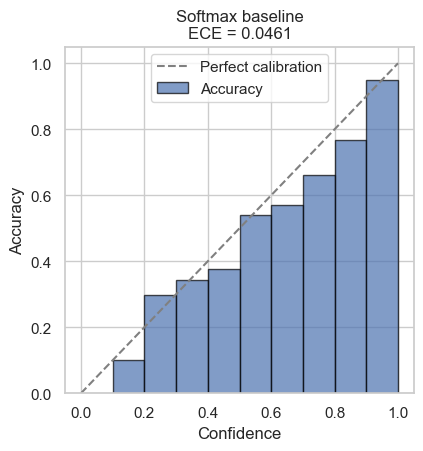

In [16]:
def expected_calibration_error(confidences, correct, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    bin_data = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        mask = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_data.append((lo, hi, 0, np.nan, np.nan))
            continue
        acc = correct[mask].mean()
        conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
        bin_data.append((lo, hi, mask.sum(), acc, conf))
    return ece, bin_data

def plot_reliability_diagram(confidences, correct, title, n_bins=10):
    ece, bin_data = expected_calibration_error(confidences, correct, n_bins)
    bins_mid = [(lo+hi)/2 for lo, hi, *_ in bin_data]
    accs = [d[3] for d in bin_data]
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.bar(bins_mid, accs, width=1/n_bins, edgecolor="black", alpha=0.7, label="Accuracy")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{title}\nECE = {ece:.4f}")
    ax.legend()
    plt.show()
    return ece

correct_softmax = (softmax_preds_eval == labels_eval).astype(int)
ece_softmax = plot_reliability_diagram(softmax_conf_eval, correct_softmax, "Softmax baseline")


In [17]:
def ood_detection_auroc_aupr(id_scores, ood_scores):
    """Higher score = more confident = more likely ID. Labels: 1 = ID, 0 = OOD."""
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    auroc = roc_auc_score(labels, scores)
    aupr = average_precision_score(labels, scores)
    return auroc, aupr

for name, id_s, ood_s in [
    ("Softmax", softmax_conf_eval, softmax_conf_ood),
    ("MC-Dropout", mc_conf_eval, mc_conf_ood),
    ("Deep Ensemble", ens_conf_eval, ens_conf_ood),
]:
    auroc, aupr = ood_detection_auroc_aupr(id_s, ood_s)
    print(f"{name:15s} | OOD AUROC: {auroc:.4f} | AUPR: {aupr:.4f}")


Softmax         | OOD AUROC: 0.7204 | AUPR: 0.5875
MC-Dropout      | OOD AUROC: 0.7150 | AUPR: 0.5691
Deep Ensemble   | OOD AUROC: 0.8292 | AUPR: 0.7499


In [18]:
def conformal_coverage_and_size(sets, labels):
    covered = sets[np.arange(len(labels)), labels]
    coverage = covered.mean()
    avg_size = sets.sum(axis=1).mean()
    return coverage, avg_size

cov_eval, size_eval = conformal_coverage_and_size(conformal_sets_eval, labels_eval)
print(f"Conformal prediction on ID eval set — coverage: {cov_eval:.4f} (target {1-CONFIG['conformal_alpha']:.2f}), avg set size: {size_eval:.2f}")

# On OOD data there is no "true label" in-distribution, so we report set size only (a well-behaved
# conformal method should produce LARGER sets on OOD inputs, reflecting higher uncertainty)
ood_avg_size = conformal_sets_ood.sum(axis=1).mean()
print(f"Conformal prediction on OOD set — avg set size: {ood_avg_size:.2f} (larger = appropriately uncertain)")


Conformal prediction on ID eval set — coverage: 0.9525 (target 0.90), avg set size: 1.95
Conformal prediction on OOD set — avg set size: 2.64 (larger = appropriately uncertain)


## 6. Comparative Analysis

In [19]:
results = []
for name, id_s, ood_s in [
    ("Softmax", softmax_conf_eval, softmax_conf_ood),
    ("MC-Dropout", mc_conf_eval, mc_conf_ood),
    ("Deep Ensemble", ens_conf_eval, ens_conf_ood),
]:
    auroc, aupr = ood_detection_auroc_aupr(id_s, ood_s)
    results.append({"Method": name, "OOD AUROC": auroc, "OOD AUPR": aupr})

results.append({
    "Method": "Conformal (APS)",
    "OOD AUROC": np.nan,
    "OOD AUPR": np.nan,
    "ID Coverage": cov_eval,
    "Avg Set Size (ID)": size_eval,
    "Avg Set Size (OOD)": ood_avg_size,
})

results_df = pd.DataFrame(results)
results_df


,Method,OOD AUROC,OOD AUPR,ID Coverage,Avg Set Size (ID),Avg Set Size (OOD)
0,Softmax,0.720372,0.587505,NaN,NaN,NaN
1,MC-Dropout,0.714998,0.569148,NaN,NaN,NaN
2,Deep Ensemble,0.829202,0.749934,NaN,NaN,NaN
3,Conformal (APS),NaN,NaN,0.9525,1.9505,2.641096


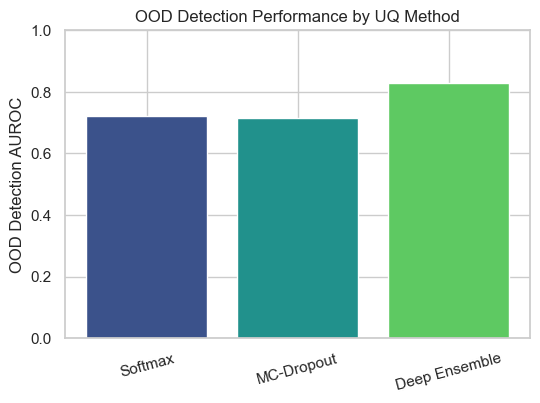

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df = results_df.dropna(subset=["OOD AUROC"])
ax.bar(plot_df["Method"], plot_df["OOD AUROC"], color=sns.color_palette("viridis", len(plot_df)))
ax.set_ylabel("OOD Detection AUROC")
ax.set_ylim(0, 1)
ax.set_title("OOD Detection Performance by UQ Method")
plt.xticks(rotation=15)
plt.show()


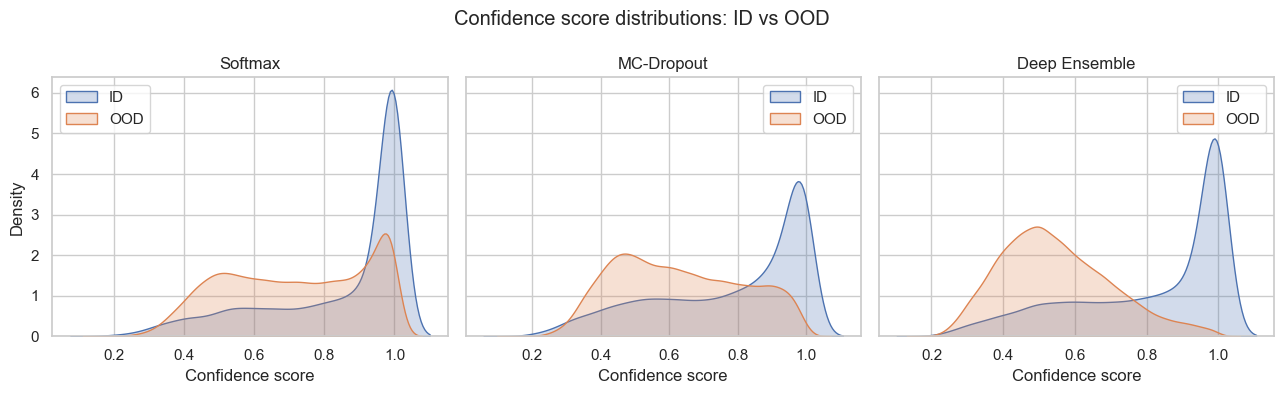

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (name, id_s, ood_s) in zip(axes, [
    ("Softmax", softmax_conf_eval, softmax_conf_ood),
    ("MC-Dropout", mc_conf_eval, mc_conf_ood),
    ("Deep Ensemble", ens_conf_eval, ens_conf_ood),
]):
    sns.kdeplot(id_s, ax=ax, label="ID", fill=True)
    sns.kdeplot(ood_s, ax=ax, label="OOD", fill=True)
    ax.set_title(name)
    ax.set_xlabel("Confidence score")
    ax.legend()
plt.suptitle("Confidence score distributions: ID vs OOD")
plt.tight_layout()
plt.show()


## 7. Stress Tests / Robustness

Rather than requiring the separately-hosted CIFAR-10-C dataset, we simulate
distribution shift by injecting Gaussian noise at increasing severities. This
keeps the notebook self-contained; swap in real CIFAR-10-C tensors here if
you have them (see README for the link).


In [22]:
class NoisyDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, sigma):
        self.base = base_dataset
        self.sigma = sigma

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if self.sigma > 0:
            x = x + torch.randn_like(x) * self.sigma
        return x, y

stress_results = []
severities = CONFIG["corruption_severities"]
print(f"[stress-test] running {len(severities)} severity levels: {severities}")
overall_t0 = time.time()

for step, sigma in enumerate(severities, start=1):
    step_t0 = time.time()
    print(f"[stress-test] ({step}/{len(severities)}) sigma={sigma} ...")

    noisy_eval = NoisyDataset(id_eval, sigma)
    noisy_loader = DataLoader(noisy_eval, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
    print(f"    batches to process: {len(noisy_loader)}")

    probs, preds, labels = get_softmax_scores(base_model, noisy_loader, desc=f"sigma={sigma}")
    acc = (preds == labels).mean()
    conf = probs.max(axis=1).mean()

    sets = aps_predict_sets(probs, qhat, desc=f"APS sigma={sigma}")
    cov, size = conformal_coverage_and_size(sets, labels)

    elapsed = time.time() - step_t0
    print(f"    done in {elapsed:.1f}s | acc={acc:.4f} conf={conf:.4f} coverage={cov:.4f} avg_set_size={size:.2f}")

    stress_results.append({
        "noise_sigma": sigma, "accuracy": acc, "mean_confidence": conf,
        "conformal_coverage": cov, "avg_set_size": size,
    })

print(f"[stress-test] all {len(severities)} severities done in {time.time()-overall_t0:.1f}s total")

stress_df = pd.DataFrame(stress_results)
stress_df


[stress-test] running 6 severity levels: [0.0, 0.05, 0.1, 0.2, 0.35, 0.5]
[stress-test] (1/6) sigma=0.0 ...
    batches to process: 63


    done in 6.5s | acc=0.8013 conf=0.8468 coverage=0.9525 avg_set_size=1.95
[stress-test] (2/6) sigma=0.05 ...
    batches to process: 63


    done in 7.2s | acc=0.7582 conf=0.8299 coverage=0.9353 avg_set_size=2.07
[stress-test] (3/6) sigma=0.1 ...
    batches to process: 63


    done in 7.2s | acc=0.6201 conf=0.7883 coverage=0.8628 avg_set_size=2.32
[stress-test] (4/6) sigma=0.2 ...
    batches to process: 63


    done in 7.1s | acc=0.3731 conf=0.7572 coverage=0.6820 avg_set_size=2.67
[stress-test] (5/6) sigma=0.35 ...
    batches to process: 63


    done in 7.4s | acc=0.2251 conf=0.7376 coverage=0.5431 avg_set_size=3.07
[stress-test] (6/6) sigma=0.5 ...
    batches to process: 63


    done in 7.1s | acc=0.1920 conf=0.6397 coverage=0.5353 avg_set_size=3.73
[stress-test] all 6 severities done in 42.5s total


,noise_sigma,accuracy,mean_confidence,conformal_coverage,avg_set_size
0,0.00,0.801250,0.846764,0.952500,1.950500
1,0.05,0.758250,0.829917,0.935250,2.069875
2,0.10,0.620125,0.788304,0.862750,2.320875
3,0.20,0.373125,0.757155,0.682000,2.666500
4,0.35,0.225125,0.737612,0.543125,3.071000
5,0.50,0.192000,0.639691,0.535250,3.728500


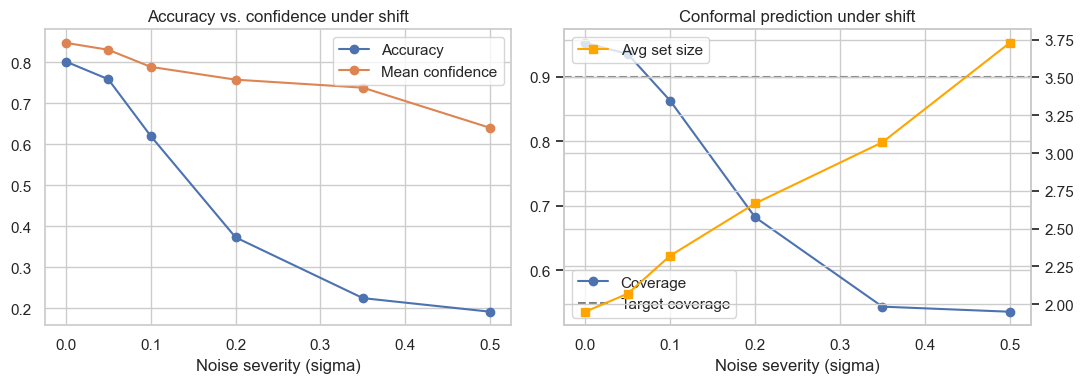

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(stress_df["noise_sigma"], stress_df["accuracy"], marker="o", label="Accuracy")
axes[0].plot(stress_df["noise_sigma"], stress_df["mean_confidence"], marker="o", label="Mean confidence")
axes[0].set_xlabel("Noise severity (sigma)")
axes[0].legend()
axes[0].set_title("Accuracy vs. confidence under shift")

axes[1].plot(stress_df["noise_sigma"], stress_df["conformal_coverage"], marker="o", label="Coverage")
axes[1].axhline(1 - CONFIG["conformal_alpha"], color="gray", linestyle="--", label="Target coverage")
ax2 = axes[1].twinx()
ax2.plot(stress_df["noise_sigma"], stress_df["avg_set_size"], marker="s", color="orange", label="Avg set size")
axes[1].set_xlabel("Noise severity (sigma)")
axes[1].set_title("Conformal prediction under shift")
axes[1].legend(loc="lower left")
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 8. Discussion / Error Analysis

Use this section to look qualitatively at failure cases:
- Highly confident but wrong predictions (softmax baseline)
- OOD samples with the smallest conformal prediction sets (worst-case failures)
- ID samples with the largest conformal prediction sets (hardest examples)


In [24]:
# Highly confident but wrong predictions
wrong_mask = softmax_preds_eval != labels_eval
wrong_conf = softmax_conf_eval[wrong_mask]
top_confident_wrong_idx = np.argsort(-wrong_conf)[:5]

print("Most confidently WRONG predictions (softmax baseline):")
wrong_indices = np.where(wrong_mask)[0][top_confident_wrong_idx]
for i in wrong_indices:
    print(f"  true={classes[labels_eval[i]]:10s} pred={classes[softmax_preds_eval[i]]:10s} conf={softmax_conf_eval[i]:.3f}")


Most confidently WRONG predictions (softmax baseline):
  true=airplane   pred=ship       conf=1.000
  true=automobile pred=truck      conf=1.000
  true=automobile pred=truck      conf=1.000
  true=bird       pred=horse      conf=1.000
  true=automobile pred=truck      conf=1.000


In [25]:
# OOD samples with the smallest (most "confidently ID") conformal sets — these are the
# cases where conformal prediction fails to flag genuinely OOD inputs
ood_set_sizes = conformal_sets_ood.sum(axis=1)
smallest_ood_idx = np.argsort(ood_set_sizes)[:5]
print("Smallest conformal set sizes on OOD data (worst-case failures to flag OOD):")
for i in smallest_ood_idx:
    print(f"  set_size={ood_set_sizes[i]}")


Smallest conformal set sizes on OOD data (worst-case failures to flag OOD):
  set_size=1
  set_size=1
  set_size=1
  set_size=1
  set_size=1


## 9. Conclusion Scaffold

Fill in after running the full pipeline. Suggested bullets to turn into the
thesis conclusion chapter:

- **Calibration**: Which method had the lowest ECE? Was softmax under- or over-confident?
- **OOD detection**: Which method achieved the highest AUROC/AUPR? Was the gap large or marginal?
- **Conformal guarantees**: Did empirical coverage match the target `1 - alpha`? Under distribution
  shift, did coverage degrade and by how much?
- **Set size behavior**: Did conformal prediction sets grow appropriately larger on OOD / shifted inputs?
  This is often the most convincing qualitative evidence for the thesis.
- **Compute trade-offs**: Note the practical cost of each method (softmax: free; MC-Dropout: ~30x
  inference cost; deep ensembles: ~5x training + inference cost; conformal: near-free on top of any
  base classifier) — this is a strong point for the thesis's "practical trustworthy ML" angle.
- **Limitations**: single seed per config, simulated corruption, single ID/OOD dataset pair.
- **Future work**: real CIFAR-10-C corruptions, additional OOD datasets, larger backbone models,
  conformal risk control beyond classification accuracy.
